# Соберем сверточную нейронную сеть LiNet5

image.png


В архитектуре нейронной сети, показанной выше:

**Слой Conv1** представляет собой сверточный слой с шестью картами признаков, размер которых составляет $28 \times 28$, функция активации $tangh$;

**Слой Pooling1** – это слой подвыборки (polling) с шестью картами признаков, размер которых составляет $14 \times 14$, функция активации $AvgPooling$;

**Слой Conv2** представляет собой сверточный слой с шестнадцатью характеристическими картами (слоями), размер которых составляет $10 \times 10$, функция активации $tangh$;

**Слой Pooling2** является слоем подвыборки с шестнадцатью характеристическими картами, размер которых составляет $5 \times 5$, функция активации $AvgPooling$;

**Слой FC** представляет собой полносвязанный слой, вход $5 \times 5 \times 16$ нейронов (признаков), выход $120$ нейронов, функция активации $tangh$;

**Слой FC** представляет собой полносвязанный слой, вход $120$ нейронов (признаков), выход $84$ нейрона, функция активации $tangh$;

**Слой FC** представляет собой полносвязанный слой, вход $84$ нейронов (признаков), выход $10$ нейронов;



In [1]:
# импортируем библиотеки

import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [2]:
# это для cuda .
torch.cuda.memory_summary(device=None, abbreviated=True)

'|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |\n|---------------------------------------------------------------------------|\n| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |\n|---------------------------------------------------------------------------|\n| Requested memory      |      0 B   |      0 B   |      0 B   |      0 B   |\n|--------------------------------------------------

In [3]:
# это для cuda. принудительно освобождение памяти, что иногда, но очень редко, помогает решить проблему с отказом
# cuda использовать память
import gc
gc.collect()

torch.cuda.empty_cache()

In [4]:
# будем использовать встроенные датасеты торча.
# полный список - тут https://pytorch.org/vision/stable/datasets.html


import torchvision.datasets

In [5]:
# загружаем сразу в трайн и тест
MNIST_train = torchvision.datasets.MNIST('./', download=True, train=True)
MNIST_test = torchvision.datasets.MNIST('./', download=True, train=False)


In [6]:
# формируем датасеты для обучения, тестирования, целевые переменные
X_train = MNIST_train.data
y_train = MNIST_train.targets
X_test = MNIST_test.data
y_test = MNIST_test.targets

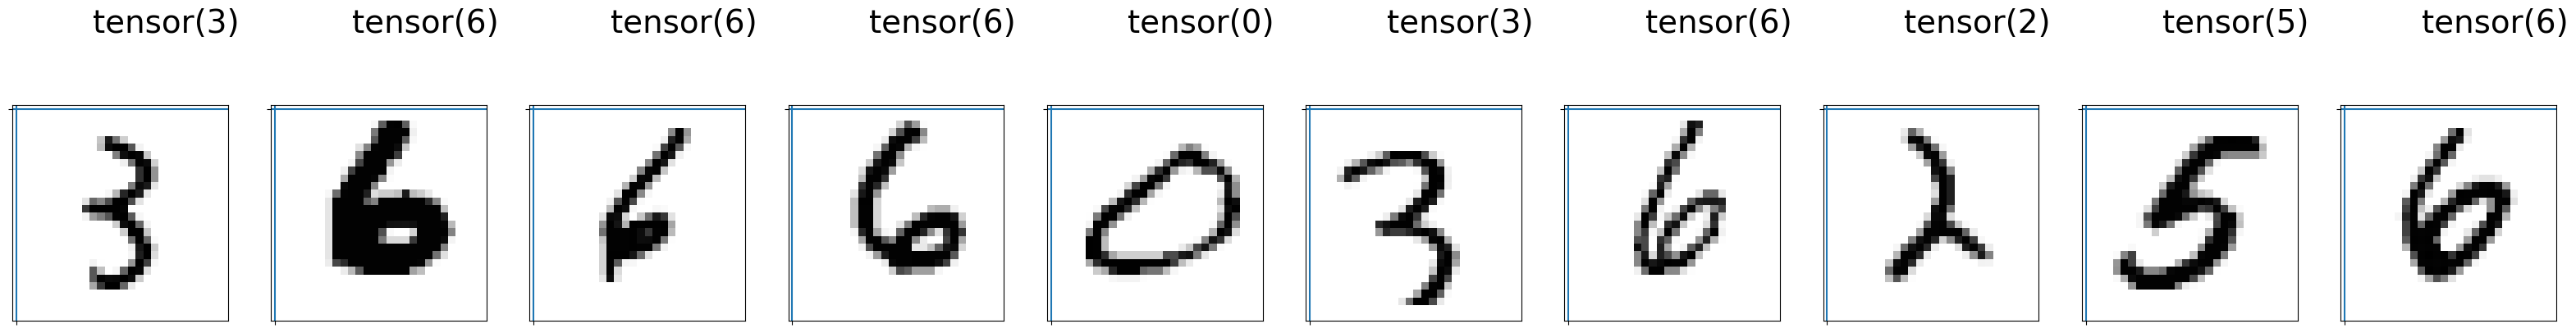

In [7]:
# посмотрим, что пришло

import numpy as np
import matplotlib.pyplot as plt

# посмотрим какие-то произвольные изображения из датасета
count = 0
sample_size = 10  # сколько картинок будем смотреть
plt.figure(figsize=(40, 20))
for i in np.random.permutation(X_train.shape[0])[:sample_size]:
    count = count + 1
    plt.subplot(1, sample_size, count)
    plt.axhline('')
    plt.axvline('')
    plt.text(x=10, y=-10, s=y_train[i], fontsize=28)
    plt.imshow(X_train[i].reshape(28, 28), cmap=plt.cm.Greys)
plt.show()

In [8]:
# сколько изображений в трейне и тесте
len(y_train), len(y_test)

(60000, 10000)

image:
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118, 219,
         166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254,
         254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0, 

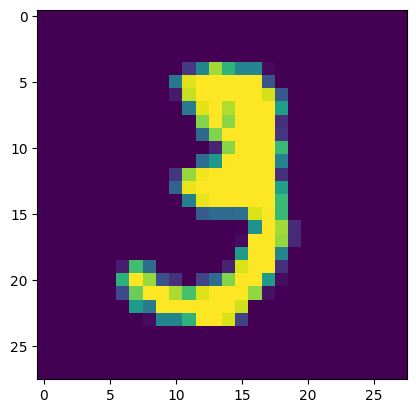

tensor(3)


In [9]:
# нарисуем, c чем мы имеем дело
import matplotlib.pyplot as plt

im_number = 10

# вот как хранятся изображения в компьютере
print(f"image:\n{X_train[im_number, :, :]}")

# а так их видим мы
plt.imshow(X_train[im_number, :, :])

plt.show()
print(y_train[im_number])

In [10]:
# посмотртим тип "картинок"
type(X_train[10, :, :])

torch.Tensor

In [11]:
X_train.shape

torch.Size([60000, 28, 28])

In [12]:
# unsqueeze - Возвращает новый тензор с увеличенной на 1 размерностью, которая вставляется в указанную позицию.
# было torch.Size([60000, 28, 28])  ---- станет torch.Size([60000, 1, 28, 28])
# и все значения - во float

X_train = X_train.unsqueeze(1).float()
X_test = X_test.unsqueeze(1).float()

In [13]:
X_train.shape

torch.Size([60000, 1, 28, 28])

In [14]:
X_test.shape

torch.Size([10000, 1, 28, 28])

In [15]:
# Определяем класс, которые и будет представлять нашу нейронку
# какие слои - см описание вначале блокнота

class LeNet5(torch.nn.Module):
    # конструктор. Определям вообще какие слои у нас будут
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = torch.nn.Conv2d(
            in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.act1  = torch.nn.Tanh()
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=0)
        self.act2  = torch.nn.Tanh()
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1   = torch.nn.Linear(5 * 5 * 16, 120)
        self.act3  = torch.nn.Tanh()

        self.fc2   = torch.nn.Linear(120, 84)
        self.act4  = torch.nn.Tanh()

        self.fc3   = torch.nn.Linear(84, 10)

    # наша самая главная функция. Определяем, что и в каком порядке будет вызываться
    def forward(self, x):

        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)

        return x

# переменная - наша нейронка
lenet5 = LeNet5()

In [16]:
# определяем, где будет обучаться наша СNN
# если есть граф процессор от Nvidia, то на нем. Если нет, то на cpu

device = torch.device('cuda:0' ) #if torch.cuda.is_available() else 'cpu'
#device = "cpu"

# отправляем туда нашу нейронку
lenet5 = lenet5.to(device)

# ЕСЛИ ВЫ ОБУЧИТЕ НЕЙРОНКУ НА GPU или CPU ОНА ДЛЯ СВОЕЙ РАБОТЫ БУДЕТ ТРЕБОВАТЬ ИЛИ GPU, ИЛИ CPU
Поэтому не всегда возможно использование обучения на GPU просто потому, что сервер или компьютер пользователя не будет поддерживать расчеты на GPU

In [17]:
# в качестве функции потерь будем использовать CrossEntropyLoss()
loss = torch.nn.CrossEntropyLoss()

# в качестве оптимайзера, который будет вычислять градиенты и минимизировать функцию потерь, будем использовать Adam (Адаптивная оценка момента)
optimizer = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [18]:
# будем оптимизировать по 100 параметров одним комплектом (бачем)
batch_size = 100

# чтобы посмотреть, как и что у нас тут менялось при оптимизации на тестовой выборке
test_accuracy_history = []
test_loss_history = []


train_loss_history = []

# не забываем отправить все выборки на устройство, на котором обучаем
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(15):
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        # обязательно обнуляем градиенты
        optimizer.zero_grad()

        # берем пачку параметров
        batch_indexes = order[start_index:start_index+batch_size]

        X_batch = X_train[batch_indexes].to(device)
        y_batch = y_train[batch_indexes].to(device)

        # делаем предсказание
        preds = lenet5.forward(X_batch)

        # считаем лосс значение
        loss_value = loss(preds, y_batch)

        # берем градиенты
        loss_value.backward()

        # и пусть оптимайзер все оптимизирует
        optimizer.step()

    # смотрим, что он тут нам напредсказывал, не забывая вовремя отправлять на cpu
    train_loss_history.append(loss_value.data.cpu())

    test_preds = lenet5.forward(X_test)
    test_loss_history.append(loss(test_preds, y_test).data.cpu())


    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    print(f"epoch{epoch} - accuracy test {accuracy} ")

epoch0 - accuracy test 0.9768999814987183 
epoch1 - accuracy test 0.9820999503135681 
epoch2 - accuracy test 0.9865999817848206 
epoch3 - accuracy test 0.9866999983787537 
epoch4 - accuracy test 0.9879999756813049 
epoch5 - accuracy test 0.9884999990463257 
epoch6 - accuracy test 0.9888999462127686 
epoch7 - accuracy test 0.9887999892234802 
epoch8 - accuracy test 0.9873999953269958 
epoch9 - accuracy test 0.9884999990463257 
epoch10 - accuracy test 0.9888999462127686 
epoch11 - accuracy test 0.9882999658584595 
epoch12 - accuracy test 0.9874999523162842 
epoch13 - accuracy test 0.9884999990463257 
epoch14 - accuracy test 0.9850999712944031 


C:\Users\leous\AppData\Local\Temp\ipykernel_29644\422858666.py:3: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


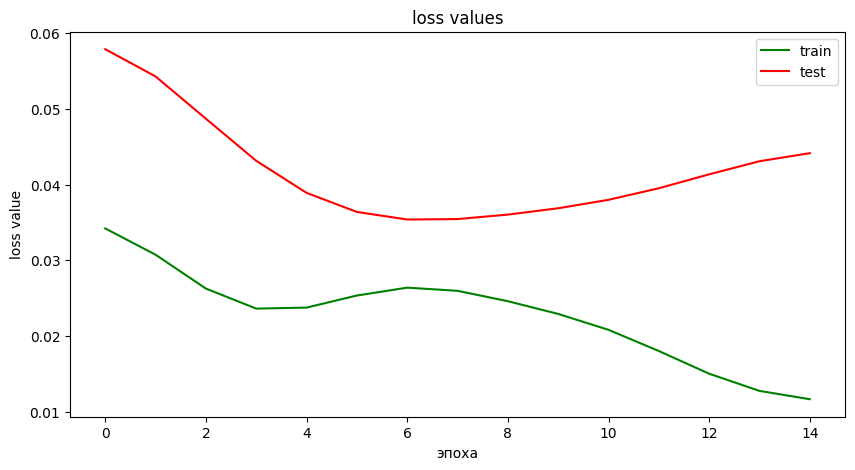

In [19]:
# строим графики - функции потерь

from scipy.ndimage.filters import gaussian_filter1d
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111)
ax.set(title = 'loss values',
       xlabel = 'эпоха',
       ylabel = 'loss value')
train_loss_smoothed = gaussian_filter1d(train_loss_history, sigma=2)
ax.plot(train_loss_smoothed, color='green',  label='train')

test_loss_smoothed = gaussian_filter1d(test_loss_history, sigma=2)
ax.plot(test_loss_smoothed, color='red',  label='test')
ax.legend()
plt.show()



C:\Users\leous\AppData\Local\Temp\ipykernel_29644\2679742005.py:3: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


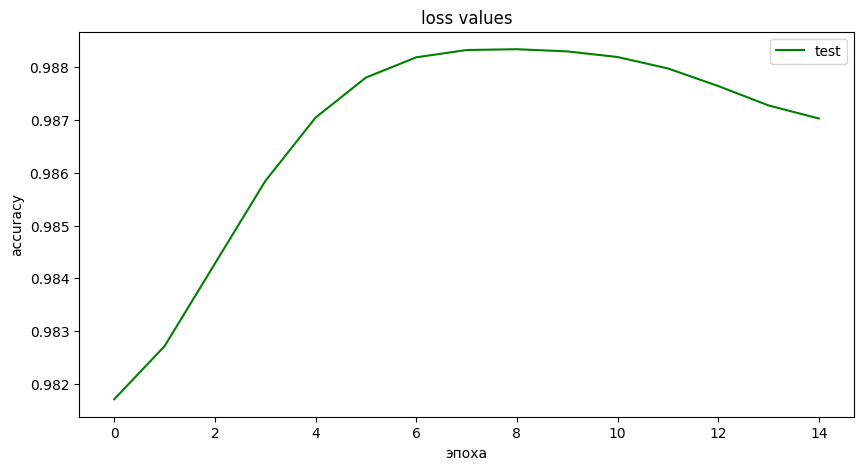

In [20]:
# График изменения accuracy на тестовых данных

from scipy.ndimage.filters import gaussian_filter1d
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111)
ax.set(title = 'loss values',
       xlabel = 'эпоха',
       ylabel = 'accuracy')
test_accuracy_smoothed = gaussian_filter1d(test_accuracy_history, sigma=2)
ax.plot(test_accuracy_smoothed, color='green',  label='test')

ax.legend()
plt.show()


# Сохранение и использование модели

In [21]:
# сохраняем произвольное число из датасета (тензор) в файл
timg = X_train[0]

torch.save(timg,'tensor.pt')


In [22]:
# смотрим размер тензора - изображения
timg.size()

torch.Size([1, 28, 28])

In [23]:
# и размер того, что изначально скармливали нейронке.
# тензор подобного размера надо будет скормить нейронке для предсказания

X_test.size()

# то есть нам нужен тензор размера [1,1,28,28]

torch.Size([10000, 1, 28, 28])

In [24]:
# !pip install dill

In [25]:
# вот так сохраняют модель с помощью dill
import dill

with open("model.dill", "wb") as dill_file:
    dill.dump(lenet5, dill_file)


In [26]:
# вот так сохраняют модель с помощью pickle
import pickle

with open("model.pickle", "wb") as pickle_file:
    pickle.dump(lenet5, pickle_file)



In [27]:
# считываем модель, сохраненную в dill

ifile = open("model.dill", "rb")
modelp = dill.load(ifile)
ifile.close()

# загружаем наше изображение
test_data = torch.load('tensor.pt')

# смотрим, что пришло из dill файла
print(modelp)


LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (act1): Tanh()
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (act2): Tanh()
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (act3): Tanh()
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (act4): Tanh()
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [28]:
# смотрим тип модели
type(modelp)

__main__.LeNet5

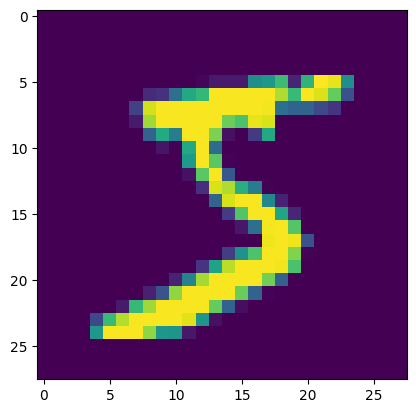

In [29]:
# смотрим, что за цифру считали
plt.imshow(test_data[0, :, :])
plt.show()

In [30]:
# переводим входной тензор-изображение в тензор нужного нам размера
t_data = torch.tensor([test_data.numpy()])

C:\Users\leous\AppData\Local\Temp\ipykernel_29644\3192455546.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  t_data = torch.tensor([test_data.numpy()])


In [31]:
# проверяем
t_data.shape

torch.Size([1, 1, 28, 28])

In [32]:
# проверяем, на чем можем считать
dev = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# отправляем туда модель
modelp.to(dev)
model_data = modelp.to(dev)

# тензор-изображение тоже
t_data = t_data.to(dev)

In [33]:
# делаем предсказание
preds = modelp.forward(t_data)

In [34]:
# в каком виде получаем предсказание. Это вектор 10x1 с вероятностями принадлежности объекта к определенному классу
print(preds)

tensor([[-2.6172, -3.4942, -6.3348,  8.8763, -3.7772, 13.1635, -2.3414, -2.6644,
         -1.2613, -0.3123]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [35]:
# выбираем максимальную вероятность, как результат предсказания.
# Не забывая отправить на cpu
prediction = np.argmax(preds.to('cpu').detach().numpy(),axis=1)

In [36]:
# смотрим, что предсказалось
print(prediction)

[5]


Цифра предсказана верно.

**Упражнение. Выберите случайным образом изображение из тестового набора и сделайте предсказание для него.**

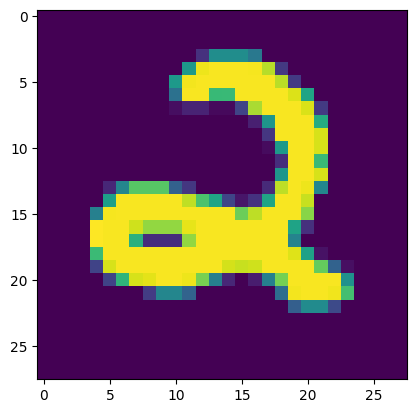

[2]


In [37]:
timg = X_test[random.randint(0,X_test.shape[0])]
if isinstance(timg, torch.Tensor):
    timg = timg.cpu().numpy() 
plt.imshow(timg[0, :, :])
plt.show()
t_data = torch.tensor([timg])
dev = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
modelp.to(dev)
model_data = modelp.to(dev)
t_data = t_data.to(dev)
preds = modelp.forward(t_data)
prediction = np.argmax(preds.to('cpu').detach().numpy(),axis=1)
print(prediction)

***Задание. Реализовать классификацию изображений на своем датасете.***

1. Выберите датасет для классификации изображений https://pytorch.org/vision/stable/datasets.html
2. Определите архитектуру нейросети и приведите ее описание (текстом или иным способом) в своей работе
3. Реализуйте выбранную архитектуру в виде класса
4. Обучите нейросеть 
5. Постройте на одном графике кривые изменения функции потерь на тесте и обучении
6. Постройте график изменения выбранной метрики качества на тесте
7. Сохраните в файл одно изображение из тестовой выборки
8. Сохраните обученную нейросеть в файл
9. Загрузите изображение из файла
10. Загрузите нейросеть
11. Выполните предсказание с помощью загруженной из файла нейросети и оцените его правильность

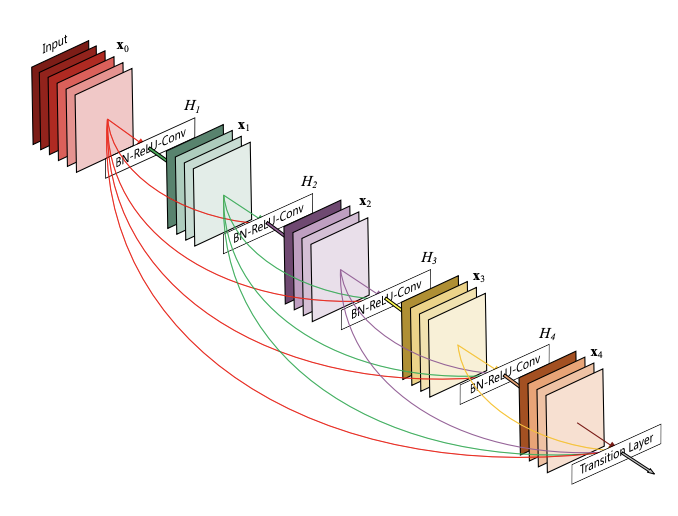

Выбранный датасет - Caltech 101 - 101 класс по 40-800 изображений на каждый. Всего около 9000 изображений

In [38]:
Caltech101_dt = torchvision.datasets.Caltech101('./.Hide', download=True)

In [39]:
len(Caltech101_dt.categories)

101

In [40]:
from torchvision import transforms
from torch.utils.data import Subset, DataLoader

# Определяем преобразование данных
transform = transforms.Compose([
    transforms.Lambda(lambda x: x[0] if isinstance(x, tuple) else x),  # Извлекаем изображение из кортежа
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.expand(3, -1, -1) if x.size(0) == 1 else x),  # Преобразование одноканальных изображений в трёхканальные
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# Применяем преобразование к исходному датасету
Caltech101_dt.transform = transform

# Определяем количество данных
num_samples = len(Caltech101_dt)

# Перемешиваем индексы всего датасета
indices = torch.randperm(num_samples)

# Определяем индексы для train, test и validation
train_size = int(0.7 * num_samples)  # 70% для train
test_size = int(0.2 * num_samples)   # 20% для test
val_size = num_samples - train_size - test_size  # 10% для validation

# Разделяем индексы на train, test и validation
train_indices = indices[:train_size]
test_indices = indices[train_size:train_size + test_size]
val_indices = indices[train_size + test_size:]

# Создаем подмножества данных
train_dataset = Subset(Caltech101_dt, train_indices)
test_dataset = Subset(Caltech101_dt, test_indices)
val_dataset = Subset(Caltech101_dt, val_indices)

# Применяем преобразование к каждому набору данных
train_dataset.transform = transform
test_dataset.transform = transform
val_dataset.transform = transform

# Создаем загрузчики данных
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

Для реализации была выбрана сверточная сеть VGG19. К сожалению, полная версия архитектуры обучается слишком долго, и было решено сократить количество сверточных слоев до 6. В любом случае, test_accuracy в ходе обучения не поднимается выше 5%, пока train_accuracy рос до 30% и выше.  
VGG19 оказалась слишком тяжелой для реализации на моей видеокарте, и я выбра другую модель

In [ ]:
import torch.nn as nn
import torchvision.models as models

class VGG19(nn.Module):
    def __init__(self):
        super(VGG19, self).__init__()
        
        # Block 1
        self.conv11 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bano11 = nn.BatchNorm2d(num_features=16)
        self.acti11 = nn.SiLU()
        self.conv12 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1)
        self.bano12 = nn.BatchNorm2d(num_features=16)
        self.acti12 = nn.SiLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2
        self.conv21 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bano21 = nn.BatchNorm2d(num_features=32)
        self.acti21 = nn.SiLU()
        self.conv22 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.bano22 = nn.BatchNorm2d(num_features=32)
        self.acti22 = nn.SiLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 3
        self.conv31 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bano31 = nn.BatchNorm2d(num_features=64)
        self.acti31 = nn.SiLU()
        self.conv32 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bano32 = nn.BatchNorm2d(num_features=64)
        self.acti32 = nn.SiLU()
        
        self.conv33 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bano33 = nn.BatchNorm2d(num_features=64)
        self.acti33 = nn.SiLU()
        self.conv34 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.bano34 = nn.BatchNorm2d(num_features=64)
        self.acti34 = nn.SiLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # # Block 4
        self.conv41 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bano41 = nn.BatchNorm2d(num_features=128)
        self.acti41 = nn.SiLU()
        self.conv42 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bano42 = nn.BatchNorm2d(num_features=128)
        self.acti42 = nn.SiLU()
        self.conv43 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bano43 = nn.BatchNorm2d(num_features=128)
        self.acti43 = nn.SiLU()
        self.conv44 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bano44 = nn.BatchNorm2d(num_features=128)
        self.acti44 = nn.SiLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # # Block 5
        self.conv51 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bano51 = nn.BatchNorm2d(num_features=128)
        self.acti51 = nn.SiLU()
        self.conv52 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bano52 = nn.BatchNorm2d(num_features=128)
        self.acti52 = nn.SiLU()
        self.conv53 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bano53 = nn.BatchNorm2d(num_features=128)
        self.acti53 = nn.SiLU()
        self.conv54 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bano54 = nn.BatchNorm2d(num_features=128)
        self.acti54 = nn.SiLU()
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fl = nn.Flatten()
        # Dense layers
        self.fc1 = nn.Linear(128 * 7 * 7, 4096)
        # self.fc1 = nn.Linear(256 * 28 * 28, 4096)
        self.acti_fc1 = nn.SiLU()
        self.fc2 = nn.Linear(4096, 4096)
        self.acti_fc2 = nn.SiLU()
        self.fc3 = nn.Linear(4096, 101)  # Output for 2 classes
        self.acti_fc3 = nn.SiLU()

    def forward(self, x):
        # print(x.size)
        # Block 1
        x = self.conv11(x)
        x = self.bano11(x)
        x = self.acti11(x)
        x = self.conv12(x)
        x = self.bano12(x)
        x = self.acti12(x)
        x = self.pool1(x)
        
        # Block 2
        x = self.conv21(x)
        x = self.bano21(x)
        x = self.acti21(x)
        x = self.conv22(x)
        x = self.bano22(x)
        x = self.acti22(x)
        x = self.pool2(x)
        
        # Block 3
        x = self.conv31(x)
        x = self.bano31(x)
        x = self.acti31(x)
        x = self.conv32(x)
        x = self.bano32(x)
        x = self.acti32(x)
        x = self.conv33(x)
        x = self.bano33(x)
        x = self.acti33(x)
        x = self.conv34(x)
        x = self.bano34(x)
        x = self.acti34(x)
        x = self.pool3(x)
        
        # # Block 4
        x = self.conv41(x)
        x = self.bano41(x)
        x = self.acti41(x)
        x = self.conv42(x)
        x = self.bano42(x)
        x = self.acti42(x)
        x = self.conv43(x)
        x = self.bano43(x)
        x = self.acti43(x)
        x = self.conv44(x)
        x = self.bano44(x)
        x = self.acti44(x)
        x = self.pool4(x)
        
        # # Block 5
        x = self.conv51(x)
        x = self.bano51(x)
        x = self.acti51(x)
        x = self.conv52(x)
        x = self.bano52(x)
        x = self.acti52(x)
        x = self.conv53(x)
        x = self.bano53(x)
        x = self.acti53(x)
        x = self.conv54(x)
        x = self.bano54(x)
        x = self.acti54(x)
        x = self.pool5(x)
        
        # Flatten
        x = self.fl(x)
        # print(x.shape)
        # Dense layers
        x = self.fc1(x)
        x = self.acti_fc1(x)
        x = self.fc2(x)
        x = self.acti_fc2(x)
        x = self.fc3(x)
        x = self.acti_fc3(x)
        
        return x

# переменная - наша нейронка
# model = VGG19()
# model = models.resnet18(pretrained=False)
# if torch.cuda.device_count() > 1:
#     model = torch.nn.DataParallel(model)

Новая модель - DenseNet121  
Состоит из следующих частей:  
1. DenseLayer:
* Это основной строительный блок DenseNet. Он состоит из:  
    * Batch Normalization.  
    * Свертки 3x3.  
    * Активации SiLU.  
* Входные данные объединяются с выходными (конкатенация по каналам).  
2. DenseBlock:  
* Состоит из нескольких DenseLayer.  
* Каждый слой добавляет growth_rate каналов к входным данным.  
3. TransitionLayer:  
* Уменьшает количество каналов и размерность изображения.  
* Состоит из:  
    * Batch Normalization.  
    * Свертки 1x1.  
    * Average Pooling 2x2.  
  
Итого DenseNet121:  
* Начальная свертка и пулинг.  
* Четыре блока DenseBlock с TransitionLayer между ними.  
* Финальный Batch Normalization и Global Average Pooling.  
* Полносвязный слой для классификации.  

In [42]:
import torch.nn.functional as F

class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)
        self.activation = nn.SiLU()

    def forward(self, x):
        out = self.conv(self.activation(self.bn(x)))
        out = torch.cat([x, out], dim=1)  # Concatenate along the channel dimension
        return out

class DenseBlock(nn.Module):
    def __init__(self, in_channels, num_layers, growth_rate):
        super(DenseBlock, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.activation = nn.SiLU()

    def forward(self, x):
        out = self.conv(self.activation(self.bn(x)))
        out = self.pool(out)
        return out

class DenseNet121(nn.Module):
    def __init__(self, num_classes=101, growth_rate=32, block_config=(6, 12, 24, 16)):
        super(DenseNet121, self).__init__()
        self.num_classes = num_classes
        self.growth_rate = growth_rate

        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.activation = nn.SiLU()
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Dense blocks
        in_channels = 64
        self.dense_blocks = nn.ModuleList()
        self.transition_layers = nn.ModuleList()
        for i, num_layers in enumerate(block_config):
            self.dense_blocks.append(DenseBlock(in_channels, num_layers, growth_rate))
            in_channels += num_layers * growth_rate
            if i != len(block_config) - 1:
                self.transition_layers.append(TransitionLayer(in_channels, in_channels // 2))
                in_channels = in_channels // 2

        # Final batch norm
        self.bn_final = nn.BatchNorm2d(in_channels)

        # Classifier
        self.fc = nn.Linear(in_channels, num_classes)

    def forward(self, x):
        # Initial convolution
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = self.pool1(x)

        # Dense blocks and transition layers
        for i in range(len(self.dense_blocks)):
            x = self.dense_blocks[i](x)
            if i != len(self.dense_blocks) - 1:
                x = self.transition_layers[i](x)

        # Final batch norm and global average pooling
        x = self.bn_final(x)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)

        # Classifier
        x = self.fc(x)
        return x

# Создаем модель
model = DenseNet121(num_classes=101)

In [43]:
from torchinfo import summary
summary(model, input_size=(32, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
DenseNet121                                   [32, 101]                 --
├─Conv2d: 1-1                                 [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                            [32, 64, 112, 112]        128
├─SiLU: 1-3                                   [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                              [32, 64, 56, 56]          --
├─ModuleList: 1-11                            --                        (recursive)
│    └─DenseBlock: 2-1                        [32, 256, 56, 56]         --
│    │    └─ModuleList: 3-1                   --                        250,560
├─ModuleList: 1-10                            --                        (recursive)
│    └─TransitionLayer: 2-2                   [32, 128, 28, 28]         --
│    │    └─BatchNorm2d: 3-2                  [32, 256, 56, 56]         512
│    │    └─SiLU: 3-3                         [32, 256, 56, 56]    

In [44]:
from tqdm import tqdm  # Импортируем tqdm
import os
# Проверка доступности CUDA
if torch.cuda.is_available():
    print("CUDA доступна! Можно использовать GPU.")
else:
    print("CUDA недоступна. Будет использован CPU.")

print(torch.version.cuda)  # Версия CUDA, с которой собран PyTorch
print(torch.cuda.is_available())  # Доступна ли CUDA

gc.collect()

torch.cuda.empty_cache()

CUDA доступна! Можно использовать GPU.
11.8
True


Служебные функции для сохранения данных и т.п.

In [45]:
import csv
def save_statistics_to_csv(statistics, filename="training_statistics.csv"):
    # Сохраняем статистику в CSV файл
    headers = ["epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy"]
    
    with open(filename, mode="w", newline='') as file:
        writer = csv.writer(file)
        writer.writerow(headers)
        for row in statistics:
            writer.writerow(row)

In [46]:

# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()  # Функция потерь для классификации
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)  # Оптимизатор Adam

gc.collect()

torch.cuda.empty_cache()

def save_checkpoint(model, optimizer, epoch, checkpoint_path, loss=None):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, checkpoint_path + str(epoch) + ".pt")

def load_checkpoint(model, optimizer, checkpoint_path):
    latest_checkpoint = None
    for i in range(100):  # Предположим, что у нас не более 100 чекпоинтов
        checkpoint_file = checkpoint_path + str(i) + ".pt"
        if os.path.exists(checkpoint_file):
            latest_checkpoint = checkpoint_file
        else:
            break
    
    if latest_checkpoint:
        print(f"Загружаем сохраненный чекпоинт из {latest_checkpoint}...")
        checkpoint = torch.load(latest_checkpoint)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        loss = checkpoint['loss']
        print(f"Продолжаем обучение с эпохи {start_epoch}")
        return start_epoch, loss
    else:
        print("Чекпоинт не найден, начинаем обучение с нуля.")
        return 0, None

def evaluate(model, val_loader, criterion, device):
    model.eval()  # Переводим модель в режим оценки
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Выключаем градиенты для оценки
        for data in val_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # Прямой проход
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Подсчитываем точность
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total
    return avg_val_loss, accuracy

def train(model, train_loader, val_loader, criterion, optimizer, device="cuda", epochs=10, checkpoint_path="checkpoint"):
    model.to(device)  # Перемещаем модель на нужное устройство

    # Загружаем последний чекпоинт, если он существует
    start_epoch, prev_loss = load_checkpoint(model, optimizer, checkpoint_path)

    # Списки для хранения статистики
    statistics = []

    for epoch in range(start_epoch, epochs):
        model.train()  # Переводим модель в режим обучения
        running_loss = 0.0
        correct = 0
        total = 0

        # Используем tqdm для отображения прогресса
        train_loader_tqdm = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False)
        
        for i, data in enumerate(train_loader_tqdm, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Прямой проход
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Обратное распространение и обновление параметров
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Оценка на валидации
            val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

            # Обновляем прогресс-бар
            train_loader_tqdm.set_postfix(
                loss=running_loss / (i + 1),
                accuracy=100 * correct / total,
                val_loss=val_loss,
                val_accuracy=val_accuracy
            )

            # Статистика по обучению
            train_loss = running_loss / len(train_loader)
            train_accuracy = 100 * correct / total

            # Добавляем статистику в список
            statistics.append([epoch + 1, train_loss, train_accuracy, val_loss, val_accuracy])
        
            # После завершения обучения сохраняем статистику в файл
            save_statistics_to_csv(statistics)
        
        print(f'Epoch: {epoch + 1}, Loss: {train_loss}, Accuracy: {train_accuracy}%')
        # Сохраняем чекпоинт
        save_checkpoint(model, optimizer, epoch, checkpoint_path, loss=train_loss)




In [48]:
# Запускаем обучение
train(model, train_loader, test_loader, criterion, optimizer, device="cuda" if torch.cuda.is_available() else "cpu", epochs=6, checkpoint_path="checkpoint")


Загружаем сохраненный чекпоинт из checkpoint3.pt...
Продолжаем обучение с эпохи 4


KeyboardInterrupt: 

На 4 эпохи ушло около 5 часов  
Epoch: 1, Loss: 4.504291040332694, Accuracy: 13.205993742795982%
                                                                                                                            
Epoch: 2, Loss: 3.723301098378081, Accuracy: 22.509468137658487%
                                                                                                                            
Epoch: 3, Loss: 3.1185687706658713, Accuracy: 30.11691091717438%
                                                                                                                            
Epoch: 4, Loss: 2.685581710934639, Accuracy: 38.15247818211757%

In [49]:
checkpoint_path="checkpoint"
epochs = 5
for i in range(epochs):
    if os.path.exists(checkpoint_path + str(i) + ".pt"):
        s = checkpoint_path + str(i) + ".pt"
if os.path.exists(s):
    print("Загружаем сохраненный чекпоинт...")
    checkpoint = torch.load(s, weights_only=False)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    criterion = checkpoint['loss']

Загружаем сохраненный чекпоинт...


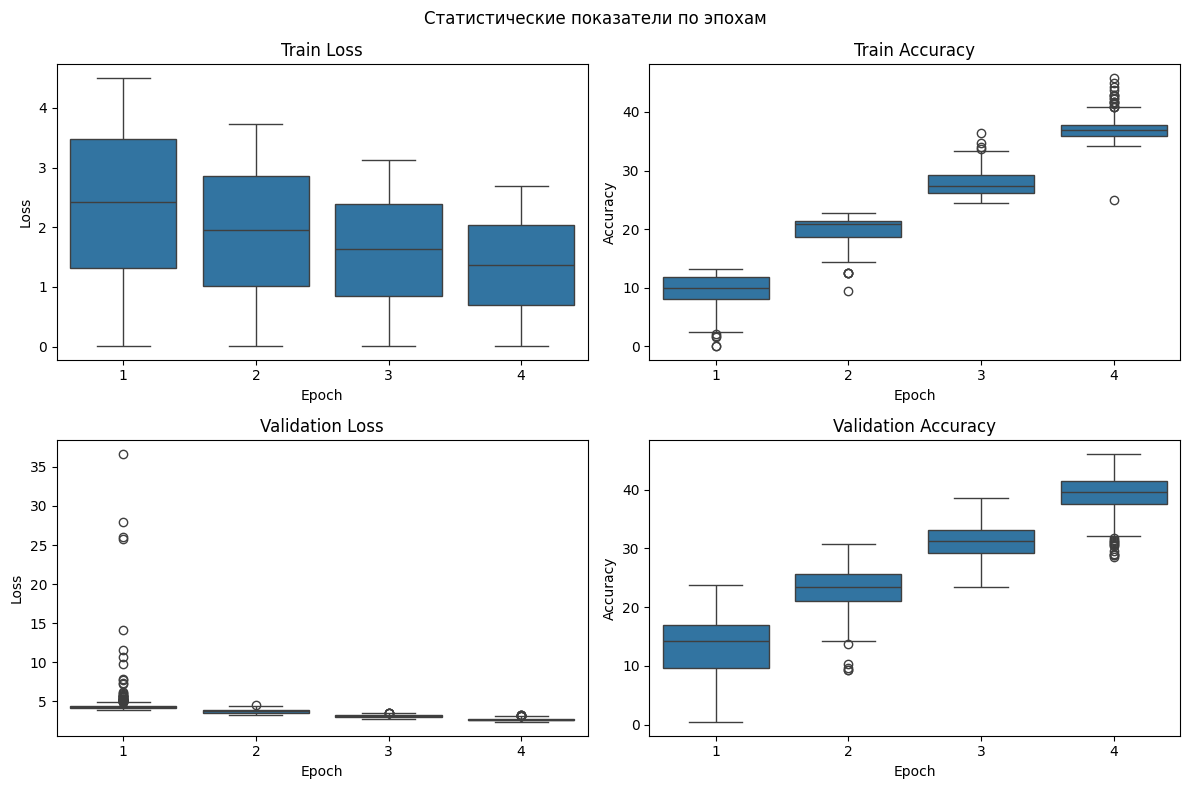

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных из CSV файла
data = pd.read_csv('training_statistics_1.csv')

# Создание графиков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Статистические показатели по эпохам')

# График для train_loss
sns.boxplot(x='epoch', y='train_loss', data=data, ax=axes[0, 0])
axes[0, 0].set_title('Train Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')

# График для train_accuracy
sns.boxplot(x='epoch', y='train_accuracy', data=data, ax=axes[0, 1])
axes[0, 1].set_title('Train Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')

# График для val_loss
sns.boxplot(x='epoch', y='val_loss', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Validation Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')

# График для val_accuracy
sns.boxplot(x='epoch', y='val_accuracy', data=data, ax=axes[1, 1])
axes[1, 1].set_title('Validation Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')

# Отображение графиков
plt.tight_layout()
plt.show()

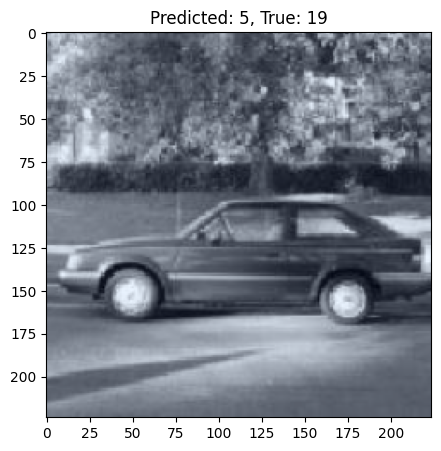

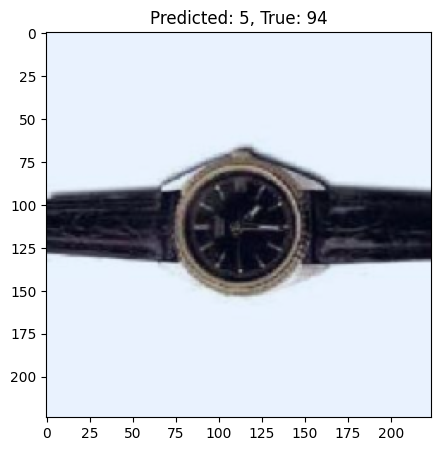

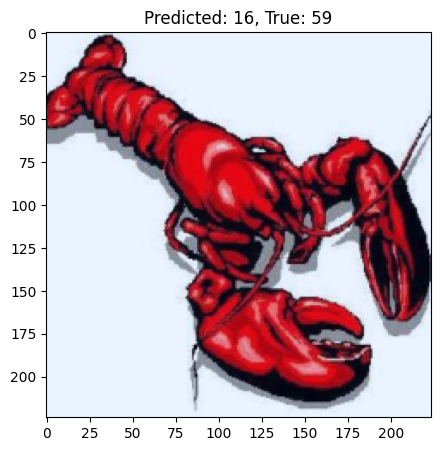

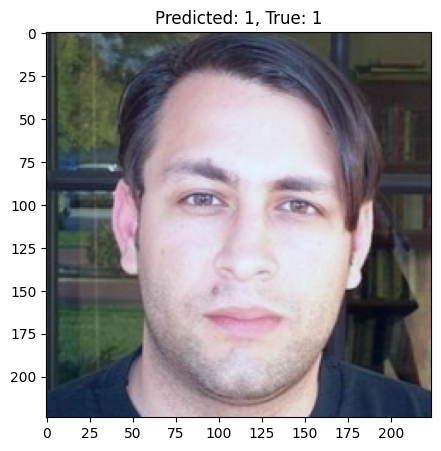

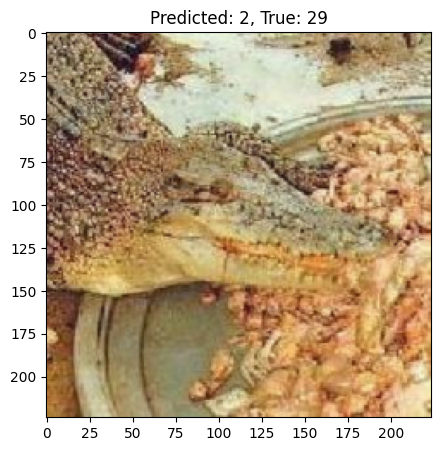

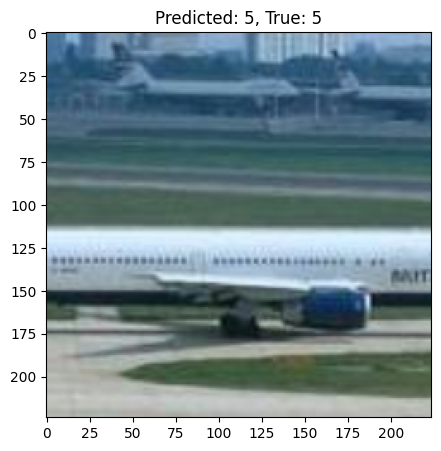

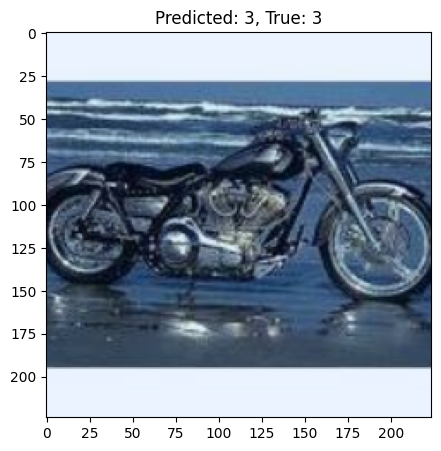

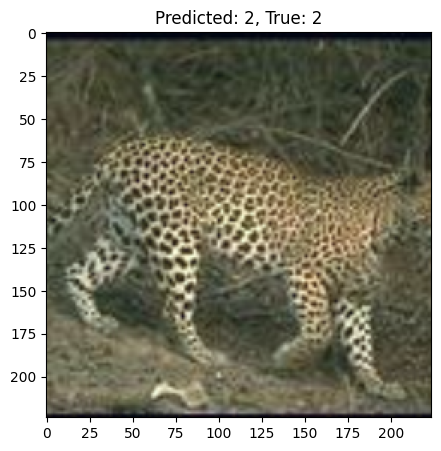

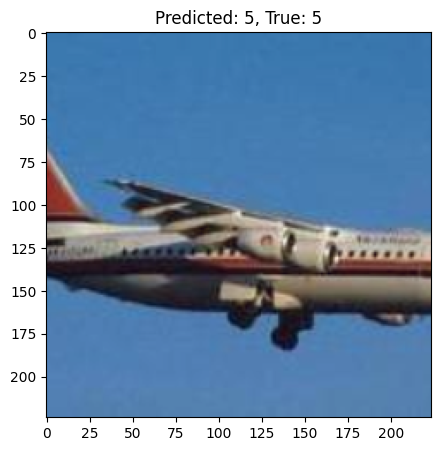

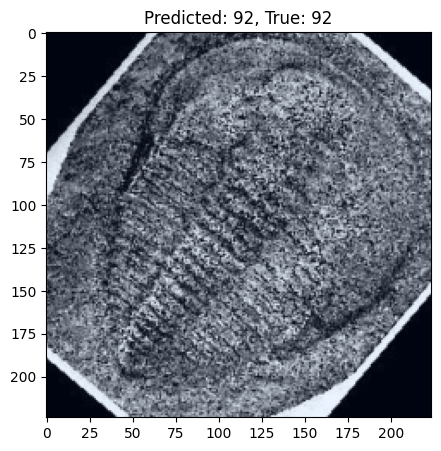

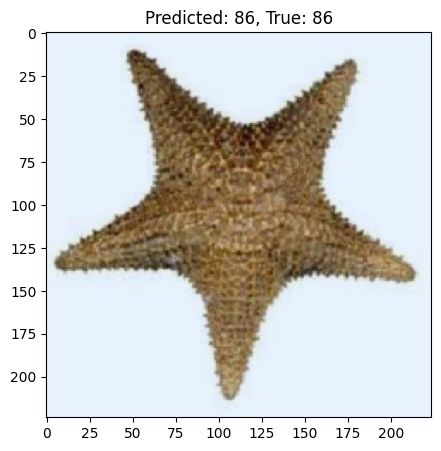

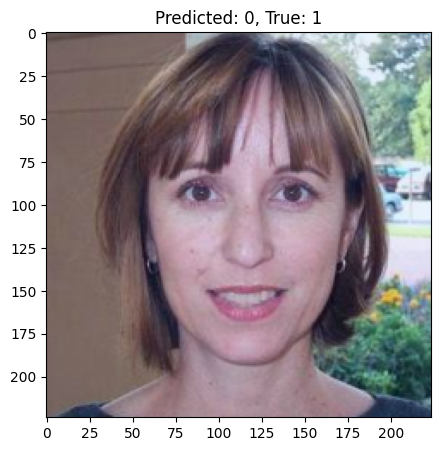

In [52]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

def show_images_and_labels(val_loader, model, device="cuda" if torch.cuda.is_available() else "cpu", num_images=5):
    model.eval()  # Устанавливаем модель в режим оценки
    model.to(device)  # Перемещаем модель на выбранное устройство

    with torch.no_grad():  # Отключаем вычисление градиентов для ускорения
        for i, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # print(outputs.data)
            _, predicted = torch.max(outputs.data, 1)
            # Выводим изображение, предсказанный лейбл и настоящий лейбл
            for j in range(min(num_images, images.size(0))):
                plt.figure(figsize=(5, 5))
                plt.imshow(torchvision.utils.make_grid(images[j].cpu(), normalize=True).permute(1, 2, 0))
                plt.title(f'Predicted: {predicted[j].item()}, True: {labels[j].item()}')
                plt.show()

            if i >= num_images:
                break

# Пример использования
# show_images_and_labels(val_loader, model, device="cuda" if torch.cuda.is_available() else "cpu", num_images=5)
show_images_and_labels(val_loader, model, device="cuda" if torch.cuda.is_available() else "cpu", num_images=3)

In [53]:
def save_images_from_loader(val_loader, save_dir="saved_images", num_images=5):
    """
    Сохраняет изображения из val_loader в указанную директорию.

    Args:
        val_loader (DataLoader): Загрузчик данных.
        save_dir (str): Директория для сохранения изображений.
        num_images (int): Количество изображений для сохранения.
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    for i, (images, labels) in enumerate(val_loader):
        for j in range(min(num_images, images.size(0))):
            # Сохраняем изображение
            image = images[j].cpu()
            image_path = os.path.join(save_dir, f"image_{i * val_loader.batch_size + j}.png")
            torchvision.utils.save_image(image, image_path)

        if i * val_loader.batch_size + j >= num_images - 1:
            break

    print(f"Сохранено {num_images} изображений в директорию {save_dir}")

In [54]:
def show_images_and_labels(val_loader, model, device="cuda" if torch.cuda.is_available() else "cpu", num_images=5):
    """
    Отображает изображения, предсказанные и истинные метки.

    Args:
        val_loader (DataLoader): Загрузчик данных.
        model (nn.Module): Модель для предсказания.
        device (str): Устройство для вычислений (CPU или CUDA).
        num_images (int): Количество изображений для отображения.
    """
    model.eval()  # Устанавливаем модель в режим оценки
    model.to(device)  # Перемещаем модель на выбранное устройство

    with torch.no_grad():  # Отключаем вычисление градиентов для ускорения
        for i, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            # Выводим изображение, предсказанный лейбл и настоящий лейбл
            for j in range(min(num_images, images.size(0))):
                plt.figure(figsize=(5, 5))
                plt.imshow(torchvision.utils.make_grid(images[j].cpu(), normalize=True).permute(1, 2, 0))
                plt.title(f'Predicted: {predicted[j].item()}, True: {labels[j].item()}')
                plt.axis('off')  # Отключаем оси
                plt.show()

            if i * val_loader.batch_size + j >= num_images - 1:
                break

Сохранено 5 изображений в директорию saved_images


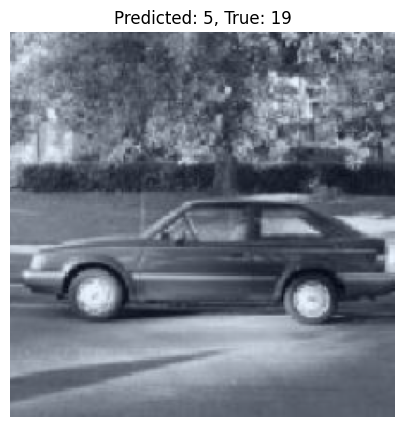

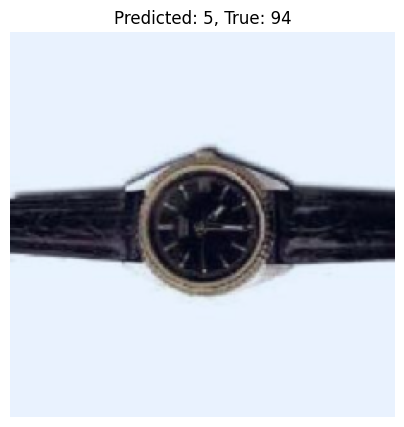

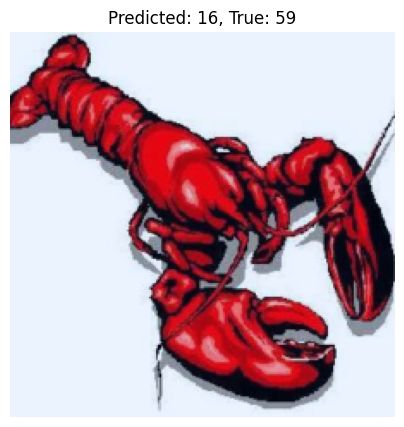

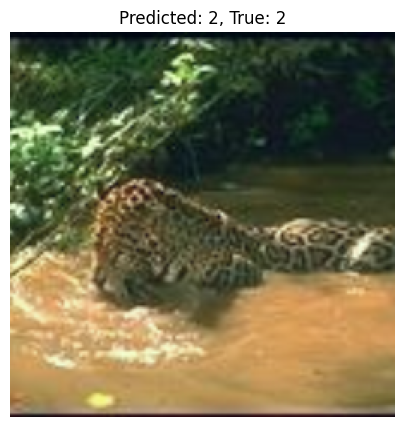

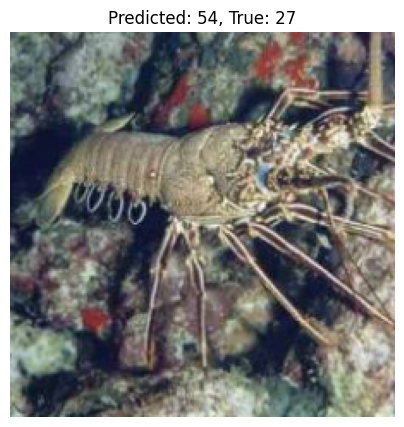

In [ ]:
# Сохраняем изображения
save_images_from_loader(val_loader, save_dir="saved_images", num_images=1)

# Отображаем изображения с предсказаниями
show_images_and_labels(val_loader, model, device="cpu", num_images=1)

Итоговая точность относительно высока, и больше случайной примерно в ~380 